### 자전거 대여량 예측(GRU)_보완된 사례

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os
import joblib  # 스케일러 저장

In [ ]:
# 1. 데이터 불러오기
dataset_path = './dataset/'
train_data = pd.read_csv(dataset_path + 'train.csv')
test_data = pd.read_csv(dataset_path + 'test.csv')

In [ ]:
# 2. 데이터 전처리
def preprocess_data(data):
    data['datetime'] = pd.to_datetime(data['datetime'])
    # 시계열 예측을 위해 시간 순 정렬
    data = data.sort_values('datetime')

    data['hour'] = data['datetime'].dt.hour
    data['day'] = data['datetime'].dt.day
    data['month'] = data['datetime'].dt.month
    data['year'] = data['datetime'].dt.year
    # 요일 정보 추가 (자전거 대여량에 중요한 변수)
    data['dayofweek'] = data['datetime'].dt.dayofweek

    # 모델 입력에 불필요한 컬럼 제거 (datetime은 인덱스로 쓰거나 제거)
    data = data.drop(['datetime'], axis=1)
    return data

In [ ]:
train_df = preprocess_data(train_data)
test_df = preprocess_data(test_data)

In [ ]:
# Feature와 Target 정의
# 학습 데이터에서 casual, registered는 제외하고 count를 타겟으로 설정
target_col = 'count'
drop_cols = ['count', 'casual', 'registered']

# X: Feature, y: Target
# errors='ignore'는 test 데이터셋에 casual, registered가 없을 경우를 대비함
X = train_df.drop(drop_cols, axis=1, errors='ignore').values
y = train_df[target_col].values.reshape(-1, 1)

In [ ]:
# 테스트 데이터 Feature 준비 (train과 동일한 컬럼 구조 유지)
X_test_raw = test_df.drop(['casual', 'registered'], axis=1, errors='ignore').values

In [ ]:
# 3. 데이터 정규화 (MinMaxScaler)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

In [ ]:
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [ ]:
# 테스트 데이터도 동일한 Scaler로 변환
X_test_scaled = scaler_X.transform(X_test_raw)

In [ ]:
# 4. 시퀀스 데이터셋 생성 함수
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

In [ ]:
# 하이퍼파라미터: 과거 몇 시간을 보고 예측할 것인가? (예: 24시간)
TIME_STEPS = 24

In [ ]:
X_seq, y_seq = create_sequences(X_scaled, y_scaled, TIME_STEPS)

print(f"Original shape: {X.shape}")
print(f"Sequence shape: {X_seq.shape}")  # (샘플수, TIME_STEPS, Feature수)

Original shape: (10886, 13)
Sequence shape: (10862, 24, 13)


In [ ]:
# 5. Train/Validation 분리 (시계열이므로 랜덤 셔플 금지)
# 시계열 데이터는 미래 데이터로 과거를 학습하면 안 되므로 순서대로 자릅니다.
train_size = int(len(X_seq) * 0.8)

X_train = X_seq[:train_size]
y_train = y_seq[:train_size]
X_val = X_seq[train_size:]
y_val = y_seq[train_size:]

In [ ]:
# 6. GRU 모델 생성
# input_shape=(시간축 길이, 특성 개수)
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 24, 64)         │        15,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,609 (96.13 KB)

 Trainable params: 24,609 (96.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 콜백(Callback) 설정 및 폴더 생성
# ==========================================================

# 01. 모델 저장 폴더가 없으면 생성
if not os.path.exists('model'):
    os.makedirs('model')

# 02. ModelCheckpoint 설정
# 가장 중요한 부분: val_loss가 가장 낮을 때만 파일로 저장합니다.
checkpoint_path = './model/best_bike_gru_model.h5'

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,  # 저장할 경로
    monitor='val_loss',        # 기준: 검증 손실
    save_best_only=True,       # True: 이전보다 좋아졌을 때만 덮어쓰기 (최적 모델 저장)
    mode='min',                # loss는 낮을수록 좋으므로 min
    verbose=1                  # 저장될 때 로그 출력
)

# 03. EarlyStopping 설정
# 학습이 더 이상 개선되지 않으면 중단하여 시간을 절약합니다.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,               # 5번(Epoch) 동안 성능 향상이 없으면 중단
    restore_best_weights=True  # 중요: 멈춘 뒤, 메모리의 model 가중치를 '가장 좋았던 때'로 복구
)

In [ ]:
# 7. 모델 학습
# callbacks 옵션에 위에서 만든 checkpoint와 early_stopping을 리스트로 전달
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1,
    shuffle=False,
    callbacks=[checkpoint, early_stopping] # ★ 핵심 수정 사항
)

Epoch 1/50
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0224
Epoch 1: val_loss improved from inf to 0.02712, saving model to ./model/best_bike_gru_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0224 - val_loss: 0.0271
Epoch 2/50
268/272 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0118
Epoch 2: val_loss improved from 0.02712 to 0.02706, saving model to ./model/best_bike_gru_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0118 - val_loss: 0.0271
Epoch 3/50
271/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0100
Epoch 3: val_loss did not improve from 0.02706
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0100 - val_loss: 0.0290
Epoch 4/50
268/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0092
Epoch 4: val_loss did not improve from 0.02706
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0092 - val_loss: 0.0289
Epoch 5/50
265/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0085
Epoch 5: val_loss improved from 0.02706 to 0.02592, saving model to ./model/best_bike_gru_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0086 - val_loss: 0.0259
Epoch 6/50
268/272 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0079
Epoch 6: val_loss improved from 0.02592 to 0.01361, saving model to ./model/best_bike_gru_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0080 - val_loss: 0.0136
Epoch 7/50
265/272 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0058
Epoch 7: val_loss improved from 0.01361 to 0.01064, saving model to ./model/best_bike_gru_model.h5


...

272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0030 - val_loss: 0.0066
Epoch 19/50
267/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027
Epoch 19: val_loss did not improve from 0.00662
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0027 - val_loss: 0.0075
Epoch 20/50
266/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027
Epoch 20: val_loss did not improve from 0.00662
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0027 - val_loss: 0.0070
Epoch 21/50
270/272 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0028
Epoch 21: val_loss improved from 0.00662 to 0.00629, saving model to ./model/best_bike_gru_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0028 - val_loss: 0.0063
Epoch 22/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0027
Epoch 22: val_loss did not improve from 0.00629
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0027 - val_loss: 0.0066
Epoch 23/50
271/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025
Epoch 23: val_loss did not improve from 0.00629
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0026 - val_loss: 0.0063
Epoch 24/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026
Epoch 24: val_loss improved from 0.00629 to 0.00613, saving model to ./model/best_bike_gru_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0026 - val_loss: 0.0061
Epoch 25/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025
Epoch 25: val_loss did not improve from 0.00613
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0025 - val_loss: 0.0065
Epoch 26/50
271/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025
Epoch 26: val_loss improved from 0.00613 to 0.00599, saving model to ./model/best_bike_gru_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0025 - val_loss: 0.0060
Epoch 27/50
268/272 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0025
Epoch 27: val_loss did not improve from 0.00599
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0025 - val_loss: 0.0066
Epoch 28/50
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025
Epoch 28: val_loss improved from 0.00599 to 0.00557, saving model to ./model/best_bike_gru_model.h5


272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0025 - val_loss: 0.0056
Epoch 29/50
267/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023
Epoch 29: val_loss did not improve from 0.00557
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0023 - val_loss: 0.0064
Epoch 30/50
270/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023
Epoch 30: val_loss did not improve from 0.00557
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0023 - val_loss: 0.0060
Epoch 31/50
269/272 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022
Epoch 31: val_loss did not improve from 0.00557
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0022 - val_loss: 0.0079
Epoch 32/50
271/272 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022
Epoch 32: val_loss did not improve from 0.00557
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0022 - val_loss: 0.0064
Epoch 33/50
267/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021
Epoch 33: val_loss did not improve from 0.00557
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - l

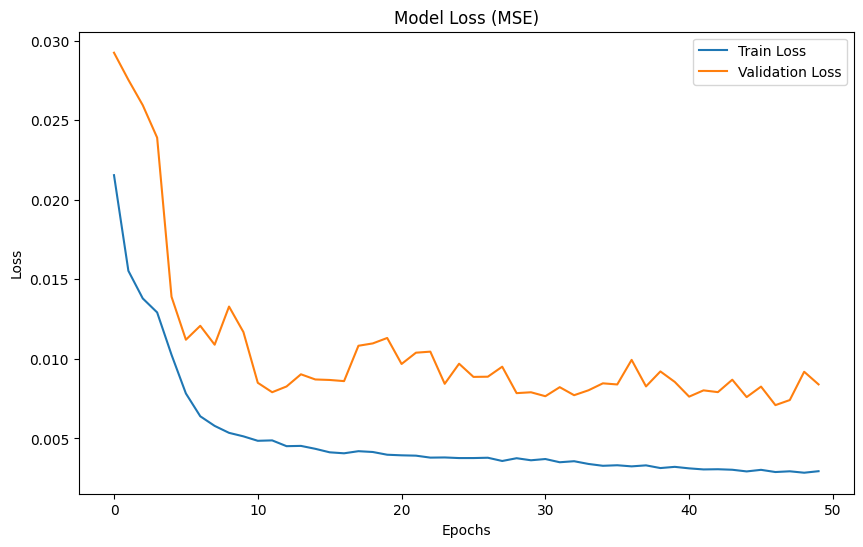

In [ ]:
# 8. 학습 과정 시각화
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
# 9. 모델 및 스케일러 저장
# model 폴더가 없으면 생성
if not os.path.exists('model'):
    os.makedirs('model')

# Keras 모델 저장 (.h5 형식)
# 중요: EarlyStopping(restore_best_weights=True)를 썼으므로,
# 여기서 저장되는 모델은 학습 중 성능이 가장 좋았던 'Best Model'입니다.
model.save('./model/bike_gru_model.h5')
print("모델이 './model/bike_gru_model.h5'에 저장되었습니다.")

# Scaler 저장 (입력값 전처리와 결과 역변환을 위해 필수)
joblib.dump(scaler_X, './model/scaler_X.pkl')
joblib.dump(scaler_y, './model/scaler_y.pkl')
print("Scaler들이 './model/' 폴더에 저장되었습니다.")

In [ ]:
# 10. 테스트 데이터 예측 준비
# 테스트 데이터의 첫 번째 row를 예측하기 위해서는 학습 데이터의 마지막 24시간(TIME_STEPS) 데이터가 필요
# 따라서 Train 데이터의 마지막 부분과 Test 데이터를 합쳐서 시퀀스를 만듭니다.
# 왜냐하면 GRU는 과거 데이터(ex. 과거 24시간)가 입력으로 들어와야하기 때문
# Train 데이터의 마지막 TIME_STEPS 만큼 가져오기
last_train_data = X_scaled[-TIME_STEPS:]

# Test 데이터 앞에 붙이기
X_test_concatenated = np.concatenate((last_train_data, X_test_scaled), axis=0)

# 시퀀스 생성 (y값은 없으므로 X만 생성하는 함수 변형 사용)
def create_test_sequences(X, time_steps):
    Xs = []
    # 데이터 전체를 순회하며 시퀀스 생성 (Concatenate 했으므로 len(test_data)만큼 생성됨)
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
    return np.array(Xs)

X_test_seq = create_test_sequences(X_test_concatenated, TIME_STEPS)

In [ ]:
# 11. 예측 및 결과 저장
y_pred = model.predict(X_test_seq)
y_pred_inverse = scaler_y.inverse_transform(y_pred)

# 음수 예측값 방지 (자전거 대여량은 0보다 작을 수 없음)
y_pred_inverse = np.maximum(y_pred_inverse, 0)  # 음수가 나오면 강제로 0으로 변경

# 결과 DataFrame에 저장
test_data['predicted_count'] = y_pred_inverse
test_data.to_csv(dataset_path + 'test_predictions.csv', index=False)

print(f"테스트 데이터 수: {len(test_data)}, 예측 결과 수: {len(y_pred_inverse)}")
print("예측 결과가 'test_predictions.csv'로 저장되었습니다.")

203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
테스트 데이터 수: 6493, 예측 결과 수: 6493
예측 결과가 'test_predictions.csv'로 저장되었습니다.


### 자전거 대여량 예측(streamlit 예제 --> streamlit_bike.py 참조)